In [20]:
#groupby()메서드 사용 
from pandas import Series, DataFrame
import numpy as np 

df = DataFrame({'key1':['a','a','b','b','a'], 
                'key2':['one','two','one','two','one'], 
                'data1':np.random.randn(5), 
                'data2':np.random.randn(5)})
df

,key1,key2,data1,data2
0,a,one,0.054175,0.733933
1,a,two,0.762575,1.688091
2,b,one,0.321466,3.106407
3,b,two,-0.476209,-1.683719
4,a,one,0.256212,-0.505465


In [37]:
grouped = df.groupby("key2")["data2"]
grouped

In [38]:
print( grouped.mean() )
print( grouped.sum() )
print( grouped.count() )

key2
one    1.111625
two    0.002186
Name: data2, dtype: float64
key2
one    3.334874
two    0.004372
Name: data2, dtype: float64
key2
one    3
two    2
Name: data2, dtype: int64


In [ ]:
#복합키컬럼을 사용하는 경우: 연속으로 함수, 메서드 호출(매서드체인)
means = df.groupby( ["key1","key2"] )["data1"].mean()
means

key1  key2
a     one     0.155194
      two     0.762575
b     one     0.321466
      two    -0.476209
Name: data1, dtype: float64

In [39]:
#학급 성적 
dfClass = DataFrame({"학급":[1,1,2,2,1], 
                     "이름":["홍길동","전우치","이순신","박문수","김길동"],
                     "국어":[100,90,95,100,80], 
                     "영어":[80,90,95,92,89], 
                     "수학":[90,80,92,100,80]
                     })

dfClass

,학급,이름,국어,영어,수학
0,1,홍길동,100,80,90
1,1,전우치,90,90,80
2,2,이순신,95,95,92
3,2,박문수,100,92,100
4,1,김길동,80,89,80


In [25]:
#합계
sum(dfClass["국어"])

465

In [26]:
#평균
sum(dfClass["국어"])/5

93.0

In [43]:
#오름차순
dfClass.sort_values("국어")

,학급,이름,국어,영어,수학
4,1,김길동,80,89,80
1,1,전우치,90,90,80
2,2,이순신,95,95,92
0,1,홍길동,100,80,90
3,2,박문수,100,92,100


In [28]:
#내림차순
dfClass.sort_values("국어", ascending=False)

,학급,이름,국어,영어,수학
0,1,홍길동,100,80,90
3,2,박문수,100,92,100
2,2,이순신,95,95,92
1,1,전우치,90,90,80
4,1,김길동,80,89,80


In [29]:
#새로운 컬럼 추가하기
dfClass["전체"] = dfClass["국어"] + dfClass["수학"] + dfClass["영어"]

In [46]:
#평균을 추가하기 
dfClass["평균"] = ((dfClass["국어"] + dfClass["수학"] + dfClass["영어"])/3).round(2)

In [47]:
dfClass

,학급,이름,국어,영어,수학,평균
0,1,홍길동,100,80,90,90.00
1,1,전우치,90,90,80,86.67
2,2,이순신,95,95,92,94.00
3,2,박문수,100,92,100,97.33
4,1,김길동,80,89,80,83.00


In [48]:
#내림차순 정렬하기 (역순)
dfClass.sort_values("평균", ascending=False)

,학급,이름,국어,영어,수학,평균
3,2,박문수,100,92,100,97.33
2,2,이순신,95,95,92,94.00
0,1,홍길동,100,80,90,90.00
1,1,전우치,90,90,80,86.67
4,1,김길동,80,89,80,83.00


In [50]:
#학급별로 그룹핑하기 
dfClass.groupby("학급")["영어"]. count()

학급
1    3
2    2
Name: 영어, dtype: int64

In [34]:
dfClass.agg(수학평균=("수학","mean"))

,수학
수학평균,88.4


In [52]:
dfClass.groupby("학급").agg(수학평균=("수학","mean")).round(2)

,수학평균
학급,
1,83.33
2,96.00


In [53]:
dfClass.groupby("학급").agg(국어평균=("국어","mean"), 
            수학평균=("수학","mean"),
            영어평균=("영어","mean"), 
            갯수=("학급","count")).round(2)

,국어평균,수학평균,영어평균,갯수
학급,,,,
1,90.0,83.33,86.33,3
2,97.5,96.00,93.50,2


Text(0.5, 1.0, 'Sine Wave')

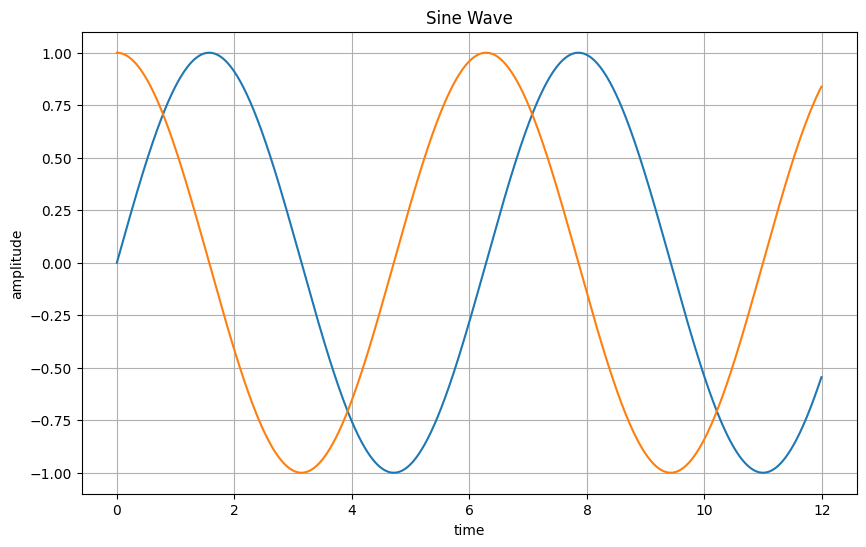

In [61]:
#차트 출력
import matplotlib.pyplot as plt
#매직명령어
%matplotlib inline
import numpy as np

t = np.arange(0, 12, 0.01)
y = np.sin(t)

plt.figure(figsize=(10, 6))
plt.plot(t, y)
plt.plot(t, np.cos(t))
plt.grid()
plt.xlabel("time")
plt.ylabel("amplitude")
plt.title("Sine Wave")


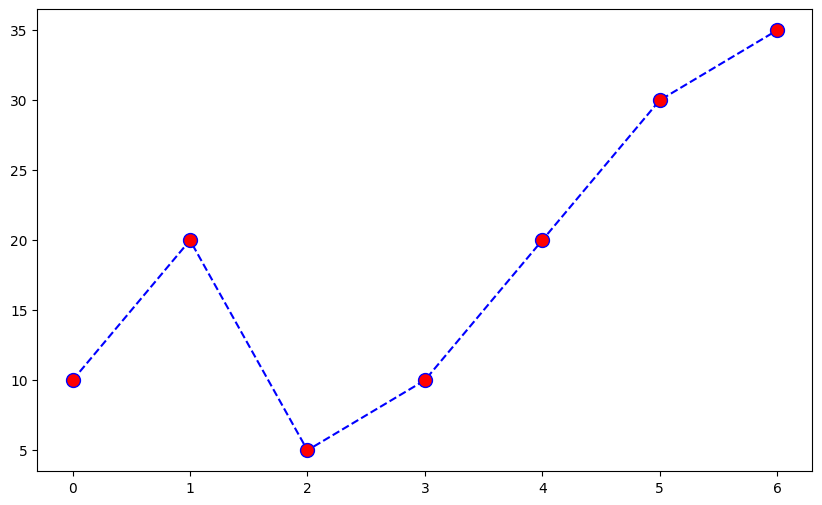

In [64]:
plt.figure(figsize=(10,6))

t = [0,1,2,3,4,5,6]
y = [10,20,5,10,20,30,35]

#마커는 강조하는 표시(o, s, >, ^)
plt.plot(t, y, color="blue", linestyle= "dashed",
         marker="o", markersize=10, markerfacecolor = "red", label="line1")